# Aplicación de librerías skforecast en la resolución de pronósticos
## Este resolución fue preparada utilizando la publicación de Joaquín Amat Rodrigo y Javier Escobar Ortiz

Atención: Esta versión utiliza skforecast 0.21.0 --> pip install "skforecast==0.21.0" montada sobre Python 3.14.3

Skforecast: forecasting series temporales con Python, Machine Learning y Scikit-learn por <b>Joaquín Amat Rodrigo y Javier Escobar Ortiz<b>, disponible bajo una licencia Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0 DEED) en https://cienciadedatos.net/documentos/py27-forecasting-series-temporales-python-scikitlearn


In [78]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme

# Modelado y Forecasting
# ==============================================================================
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster, backtesting_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.utils import save_forecaster, load_forecaster
from skforecast.metrics import calculate_coverage
from skforecast.plot import plot_prediction_intervals
import shap

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('once')

color = '\033[1m\033[38;5;208m' 
print(f"{color}Versión skforecast: {skforecast.__version__}")
print(f"{color}Versión scikit-learn: {sklearn.__version__}")
print(f"{color}Versión pandas: {pd.__version__}")
print(f"{color}Versión numpy: {np.__version__}")



Versión skforecast: 0.21.0
Versión scikit-learn: 1.8.0
Versión pandas: 2.3.3
Versión numpy: 2.4.2


In [79]:
# Descarga de datos
# ==============================================================================
datos = fetch_dataset(name='h2o_exog', raw=True)

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 4 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [80]:
# Preparación del dato
# ==============================================================================
datos['fecha'] = pd.to_datetime(datos['fecha'], format='%Y-%m-%d')
datos = datos.set_index('fecha')
datos = datos.asfreq('MS')
datos = datos.sort_index()
datos.head()


,y,exog_1,exog_2
fecha,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199


In [81]:
print(f'Número de filas con missing values: {datos.isnull().any(axis=1).mean()}')

Número de filas con missing values: 0.0


In [82]:
# Verificar que un índice temporal está completo
# ==============================================================================
fecha_inicio = datos.index.min()
fecha_fin = datos.index.max()
date_range_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq=datos.index.freq)
print(f"Índice completo: {(datos.index == date_range_completo).all()}")

Índice completo: True


### Se utilizan los últimos 36 meses como conjunto de test para evaluar la capacidad predictiva del modelo.

Fechas train : 1992-04-01 00:00:00 --- 2005-06-01 00:00:00  (n=159)
Fechas test  : 2005-07-01 00:00:00 --- 2008-06-01 00:00:00  (n=36)


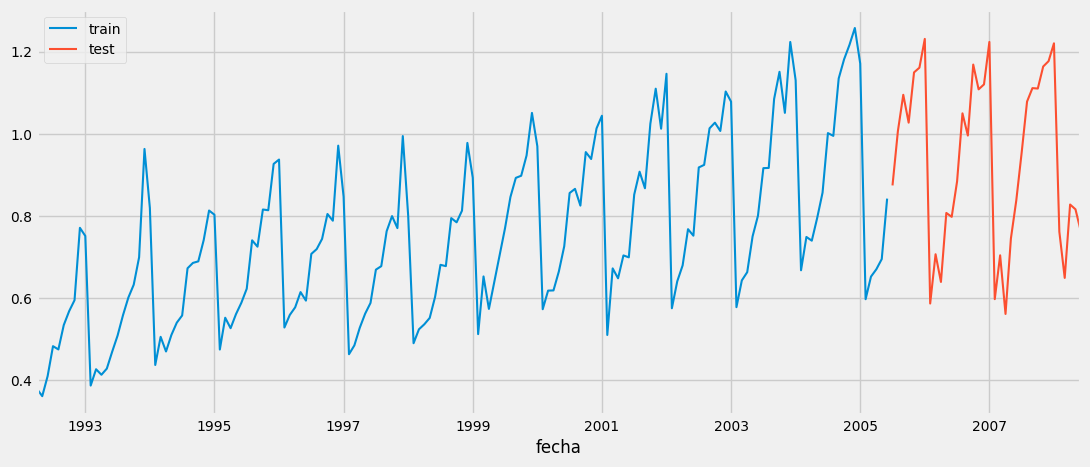

In [83]:
# Separación datos train-test
# ==============================================================================
steps = 36
datos_train = datos[:-steps]
datos_test  = datos[-steps:]
print(f"Fechas train : {datos_train.index.min()} --- {datos_train.index.max()}  (n={len(datos_train)})")
print(f"Fechas test  : {datos_test.index.min()} --- {datos_test.index.max()}  (n={len(datos_test)})")

fig, ax = plt.subplots(figsize=(12, 5))
datos_train['y'].plot(ax=ax, label='train')
datos_test['y'].plot(ax=ax, label='test')
ax.legend();

# Forecasting autorregresivo recursivo
## ForecasterAutoreg
Se crea y entrena un modelo ForecasterAutoreg a partir de un regresor RandomForestRegressor y una ventana temporal de 6 lags. Esto último significa que, el modelo, utiliza como predictores los 6 meses anteriores.

In [84]:
# Crear y entrenar forecaster
# ==============================================================================
# se utiliza una serie de 6 elementos lags = 6. 
# Este no es un buen valor ya que la serie tiene una estacionalidad anual, sería mas lógico utilizar 12
# Se hace para mostrar el funcionamiento del forecaster. 
# En la sección de optimización de hiperparámetros se muestra como encontrar el valor óptimo de lags.
forecaster = ForecasterRecursive(
                estimator = RandomForestRegressor(random_state=123),
                lags = 6
             )
forecaster.fit(y=datos_train['y'])
forecaster


=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6] 
Window features: None 
Window size: 6 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2005-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-04-05 11:06:21 
Last fit date: 2026-04-05 11:06:22 
Skforecast version: 0.21.0 
Python version: 3.14.3 
Forecaster id: None

## Predicciones
Una vez entrenado el modelo, se predicen los datos de test (36 meses a futuro).

In [85]:
# Predicciones
# ==============================================================================
steps = 36
predicciones = forecaster.predict(steps=steps)
predicciones.head(5)

2005-07-01    0.878756
2005-08-01    0.882167
2005-09-01    0.973184
2005-10-01    0.983678
2005-11-01    0.849494
Freq: MS, Name: pred, dtype: float64

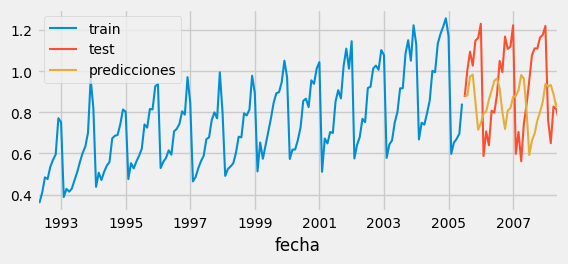

In [86]:
# Gráfico de predicciones vs valores reales
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 2.5))
datos_train['y'].plot(ax=ax, label='train')
datos_test['y'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();

## Error de predicción en los datos de test
Se cuantifica el error que comete el modelo en sus predicciones.  <br>
Se lo realiza comparando los valores pronosticados con la serie de testeo que reservamos. <br>
Se utilizan los 3 errores clásicos. <br>
<b>MAP</b>  (aquí se llama MAE mean absolute error) <br>
<b>MAPE</b> (que es la visión porcentual del error anterior) <br>
<b>MSE</b>  (error quadrático medio) <br>

In [87]:
# Error test
# ==============================================================================
error_mae = round(mean_absolute_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ),4)

error_mape = round(mean_absolute_percentage_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ) * 100,2)

error_mse = round(mean_squared_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ),4)

print(f"Error de test (MAD): {error_mae}")
print(f"Error de test (MAPE): {error_mape} %")
#print('Error de test (MAPE) %i :' %(round(error_mape,2)))
print(f"Error de test (MSE): {error_mse}")

Error de test (MAD): 0.2332
Error de test (MAPE): 25.21 %
Error de test (MSE): 0.0733


## Ajuste de hiperparámetros (tuning)
El ForecasterAutoreg entrenado ha utilizado una ventana temporal de 6 lags y un modelo Random Forest con los hiperparámetros por defecto. Sin embargo, no hay ninguna razón por la que estos valores sean los más adecuados. La librería Skforecast proporciona varias estrategias de búsqueda para encontrar la mejor combinación de hiperparámetros y lags. En este caso, se utiliza la función grid_search_forecaster, que compara los resultados obtenidos con cada combinación de hiperparámetros y lags, e identifica la mejor.

In [88]:
# Búsqueda de hiperparámetros: grid search
# ==============================================================================
forecaster = ForecasterRecursive(
                estimator = RandomForestRegressor(random_state=123),
                lags      = 6 # Este valor será remplazado en el grid search
             )

# Particiones de entrenamiento y validación
cv = TimeSeriesFold(
      steps              = 36,
      initial_train_size = int(len(datos_train) * 0.5),
      refit              = False,
      fixed_train_size   = False,

    )

# Valores candidatos de lags
lags_grid = [6, 12]

# Valores candidatos de hiperparámetros del regresor
param_grid = {
      'n_estimators': [100, 250],
      'max_depth': [3, 5, 10]
}

resultados_grid = grid_search_forecaster(
                        forecaster  = forecaster,
                        y           = datos_train['y'],
                        cv          = cv,
                        param_grid  = param_grid,
                        lags_grid   = lags_grid,
                        metric      = 'mean_squared_error',  
                        return_best = True,
                        n_jobs      = 'auto',
                        verbose     = False
                  )



lags grid: 100%|██████████| 2/2 [00:04<00:00,  2.23s/it]


In [89]:
# Resultados de la búsqueda de hiperparámetros
# ==============================================================================
resultados_grid

,lags,lags_label,params,mean_squared_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 5, 'n_estimators': 100}",0.022132,5,100
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 5, 'n_estimators': 250}",0.022481,5,250
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 10, 'n_estimators': 100}",0.022560,10,100
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 10, 'n_estimators': 250}",0.022793,10,250
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 3, 'n_estimators': 100}",0.023309,3,100
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': 3, 'n_estimators': 250}",0.023340,3,250
6,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 3, 'n_estimators': 250}",0.061352,3,250
7,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 3, 'n_estimators': 100}",0.062450,3,100
8,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 5, 'n_estimators': 100}",0.067993,5,100
9,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 10, 'n_estimators': 100}",0.069864,10,100


## Modelo final
Finalmente, se entrena de nuevo un ForecasterAutoreg con la mejor configuración encontrada. Este paso no es necesario si se indica return_best = True en la función grid_search_forecaster.

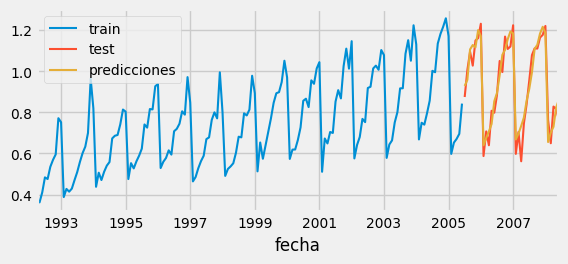

In [90]:
# Crear y entrenar forecaster con mejores hiperparámetros
# ==============================================================================
estimator = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=123)
forecaster = ForecasterRecursive(
                estimator = estimator,
                lags      = 12
             )
forecaster.fit(y=datos_train['y'])

# Predicciones
# ==============================================================================
predicciones = forecaster.predict(steps=steps)

# Gráfico de predicciones vs valores reales
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 2.5))
datos_train['y'].plot(ax=ax, label='train')
datos_test['y'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();



In [91]:
# Error test
# ==============================================================================
error_mae = round(mean_absolute_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ),4)

error_mape = round(mean_absolute_percentage_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ) * 100,2)

error_mse = round(mean_squared_error(
                y_true = datos_test['y'],
                y_pred = predicciones
            ),4)

print(f"Error de test (MAD): {error_mae}")
print(f"Error de test (MAPE): {error_mape} %")
#print('Error de test (MAPE) %i :' %(round(error_mape,2)))
print(f"Error de test (MSE): {error_mse}")

Error de test (MAD): 0.0529
Error de test (MAPE): 6.29 %
Error de test (MSE): 0.004
